<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2_ext/05_heterogeneous_effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heterogeneous Price Elasticities with Embedding-Based Effect Modifiers

This notebook is the last of five labs that accompany [Bach et al. (2025)](https://arxiv.org/abs/2501.00382). It requires the embeddings saved in **Lab 2**.

In Lab 4, we estimated a single average effect: a 1% price increase reduces units sold by roughly 1.3% to 1.5%. Sellers, however, do not set prices for the average product, so the more relevant question is which products are sensitive to prices and which are not. In this lab, we estimate the price elasticity as a function of product characteristics.

## From the ACE to the CACE

Recall that $A_{it} = a_t(S_{it}, \epsilon_{it})$ denotes the price sensitivity of product $i$ in period $t$. In Lab 4, we estimated its unconditional mean. Here, we estimate the conditional average causal effect (CACE),

$$\alpha_t(S_{it}) := E[A_{it}\mid S_{it}],$$

that is, the part of the variation in price sensitivity that can be predicted from what we observe.

Proposition 1 of the paper shows that, under the structural assumptions of Lab 4, the CACE is identified by the conditional average predictive effect,

$$
\alpha_t(S_{it}) = \delta_t(S_{it}) :=
\frac{E\!\left[Q^{\perp}_{it}P^{\perp}_{it}\mid S_{it}\right]}
     {E\!\left[(P^{\perp}_{it})^{2}\mid S_{it}\right]}.
$$

In words, we partial out the state as in Lab 4 and then let the slope of the regression of the outcome residual on the price residual vary with the characteristics of interest.

## The Specification

Following Model II of the paper, the elasticity is linear in a small set of basis functions:

$$\alpha(S_{it}) = a_0 + \sum_{k=1}^{5}\alpha_k X^{sim}_{i,k}
                 + b_1 P_{i,t-1} + b_2 Q_{i,t-1}.$$

The two kinds of effect modifiers answer different questions. The cluster similarities $X^{sim}_{i,k}$ describe what kind of product it is; Lab 3 showed that five similarities carry about as much information as the full 256-dimensional embedding, which keeps the model interpretable. Lagged price and quantity describe how expensive and how popular the product currently is.

The intercept $a_0$ is the average effect and should be close to the estimate from Lab 4.

We estimate this model in three ways, corresponding to Models II-1, II-2 and II-3 of the paper. As before, we use the estimation products only and cluster the standard errors by product.

First, we install and load the required packages.

In [1]:
%pip install -q doubleml lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.8/607.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.7/531.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00


In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from doubleml import DoubleMLData, DoubleMLPLR
from lightgbm import LGBMRegressor
from scipy.linalg import sqrtm
from scipy.stats import chi2, norm

palette = sns.color_palette("colorblind")
warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.width", 140)

CONFIDENCE = 0.90
RANK_TO_DEMAND = 2.0
SEED = 42

## Data

We load the data saved in Lab 2 from Google Drive. If the file is not found there, the cell also looks for a copy uploaded to the current session.

In [3]:
ARTIFACT = "full_v2_ext.parquet"
drive_path = f"/content/drive/MyDrive/demand_labs_v2_ext/{ARTIFACT}"

# Colab gives every notebook its own machine, so /content does not carry across
# labs. Google Drive does.
if os.path.isdir("/content") and not os.path.exists(drive_path):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"could not mount Drive ({type(exc).__name__})")

path = next((p for p in [drive_path, f"/content/{ARTIFACT}", ARTIFACT]
             if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(
        f"{ARTIFACT} not found. Run Lab 2 "
        "(02_finetune_embeddings.ipynb) first and let it save to Google Drive, "
        "or upload the file into this session.")

df = pd.read_parquet(path)
print(f"loaded {path}")
print(f"{df['ASIN'].nunique():,} products, {len(df):,} rows, "
      f"{df['period'].nunique()} periods")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size"),
                              in_sample=("in_sample", "sum")))

Mounted at /content/drive
loaded /content/drive/MyDrive/demand_labs_v2_ext/full_v2_ext.parquet
7,549 products, 83,777 rows, 14 periods
            products   rows  in_sample
split                                 
estimation      3775  41736      37940
finetune        3774  42041      38247


As in Lab 4, we define the groups of variables and restrict the sample to the estimation products.

In [4]:
emb_cols = [c for c in df.columns if c.startswith("emb_")]
pca_cols = [c for c in df.columns if c.startswith("pca_")]
sim_cols = [c for c in df.columns if c.startswith("similarity_cluster_")]
sub_cols = [c for c in df.columns if c.startswith("sub_")]

lag_controls = ["Q_t-1", "P_bb_t-1"]
tab_controls = ["RATING_t-1", "REVIEW_COUNT_t-1", "n_offers",
                "n_offers_fba", "n_offers_fbm", "lightning_deal", "is_fba"]

periods = sorted(df["period"].unique())[1:]   # first period is the baseline
period_cols = [f"period_{p}" for p in periods]
for p in periods:
    df[f"period_{p}"] = (df["period"] == p).astype(int)

OUTCOME, TREATMENT = "Q_t", "P_bb_t"
X_o = tab_controls + sub_cols + period_cols

# the estimation sample I_2, as in Lab 4
data = (df[(df["split"] == "estimation") & df["in_sample"]]
        .dropna(subset=lag_controls + tab_controls + [OUTCOME, TREATMENT])
        .reset_index(drop=True))
clusters = data["ASIN"]

print(f"estimation sample: {len(data):,} observations, "
      f"{data['ASIN'].nunique()} products")

estimation sample: 37,940 observations, 3726 products


## Basis Functions

The basis consists of an intercept and seven effect modifiers. We center and standardize the lagged variables, so that their coefficients measure the change in the elasticity per standard deviation of popularity or price. We only center the similarities, since they already share a common cosine scale.

In [5]:
def make_basis(frame, scaled, unscaled):
    """Intercept + standardised `scaled` columns + centred `unscaled` columns."""
    out = pd.DataFrame({"intercept": np.ones(len(frame))}, index=frame.index)
    for c in scaled:
        out[c] = (frame[c] - frame[c].mean()) / frame[c].std()
    for c in unscaled:
        out[c] = frame[c] - frame[c].mean()
    return out


basis = make_basis(data, scaled=lag_controls, unscaled=sim_cols)
BASIS_COLS = list(basis.columns)
SIM_IDX = [BASIS_COLS.index(c) for c in sim_cols]
MOD_IDX = [i for i, c in enumerate(BASIS_COLS) if c != "intercept"]

print("basis:", BASIS_COLS)
basis.head(3).round(3)

basis: ['intercept', 'Q_t-1', 'P_bb_t-1', 'similarity_cluster_0', 'similarity_cluster_1', 'similarity_cluster_2', 'similarity_cluster_3', 'similarity_cluster_4']


,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,-1.227,0.863,-0.389,0.189,0.053,0.355,-0.38
1,1.0,-1.115,0.863,-0.389,0.189,0.053,0.355,-0.38
2,1.0,-1.051,0.992,-0.389,0.189,0.053,0.355,-0.38


## Estimation

Models II-1 and II-2 are linear. We residualize $Q$ and $P$ on the controls by OLS and then regress the outcome residual on the basis functions interacted with the price residual. Model II-2 additionally includes interactions between the lagged state and the similarities in the control function.

Model II-3 is partially linear. The second stage is the same, but the residuals come from cross-fitted boosted trees estimated with `DoubleML`, so the control function is nonparametric. Following the paper's code, the trees control for the lagged state, the 256 embeddings and the tabular controls, and the cross-fitting uses five folds. We obtain the second stage with the `cate` method of the fitted `DoubleMLPLR` object.

In [6]:
def lin_model_cate(frame, basis, controls, treatment=TREATMENT, outcome=OUTCOME):
    """Residual-on-residual regression with a varying slope (Models II-1, II-2)."""
    X = sm.add_constant(frame[controls], has_constant="add")
    y_tilde = frame[outcome] - sm.OLS(frame[outcome], X).fit().predict(X)
    d_tilde = frame[treatment] - sm.OLS(frame[treatment], X).fit().predict(X)
    interacted = basis.mul(d_tilde.values, axis=0)
    return sm.OLS(y_tilde, interacted).fit(
        cov_type="cluster", cov_kwds={"groups": clusters})


# Model II-2 needs the interaction terms in the *control* function
inter_cols = []
for lag in lag_controls:
    for s in sim_cols:
        name = f"int_{lag}_{s}"
        data[name] = data[lag] * data[s]
        inter_cols.append(name)

controls_base = lag_controls + emb_cols + X_o

models = {}
models["II-1 Linear"] = lin_model_cate(data, basis, controls_base)
models["II-2 Linear (interactions)"] = lin_model_cate(
    data, basis, controls_base + inter_cols)
print("linear specifications fitted")

/tmp/ipykernel_2073/3995971268.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  y_tilde = frame[outcome] - sm.OLS(frame[outcome], X).fit().predict(X)
/tmp/ipykernel_2073/3995971268.py:5: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  d_tilde = frame[treatment] - sm.OLS(frame[treatment], X).fit().predict(X)
/tmp/ipykernel_2073/3995971268.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  y_tilde = frame[outcome] - sm.OLS(frame[outcome], X).fit().predict(X)
/tmp/ipykernel_2073/3995971268.py:5: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  d_tilde = frame[treatment] - sm.OLS(frame[treatment], X).fit().predict(X)


linear specifications fitted


In [ ]:
# As in the paper, the boosted trees control for the lagged state, the 256
# embeddings and the tabular controls.
dml_controls = lag_controls + emb_cols + X_o
dml_data = DoubleMLData(data[[OUTCOME, TREATMENT, "ASIN"] + dml_controls],
                        y_col=OUTCOME, d_cols=TREATMENT,
                        x_cols=dml_controls, cluster_cols="ASIN")

# The paper's script passes `lr=0.02`, which LightGBM does not recognise, so
# its trees run at the default learning rate of 0.1. We set that explicitly.
learner = dict(n_estimators=500, learning_rate=0.1, random_state=SEED, verbose=-1)
np.random.seed(3141)
plr = DoubleMLPLR(dml_data,
                  ml_l=LGBMRegressor(**learner),
                  ml_m=LGBMRegressor(**learner),
                  score="partialling out", n_folds=5)
plr.fit(store_predictions=True)
print(f"average effect: {plr.coef[0]:+.3f}")

blp = plr.cate(basis, cov_type="cluster", cov_kwds={"groups": clusters})
# recent doubleml releases keep one OLS fit per repetition; n_rep is 1 here
blp_fit = blp.blp_model
models["II-3 PLR (boosted trees)"] = blp_fit[0] if isinstance(blp_fit, list) else blp_fit

## The Elasticity Function

Model II-3 uses the same controls as the boosted-tree specification with embeddings in Lab 4, so its average effect should be close to that estimate. The `intercept` row gives the average effect, and every other row gives the change in the elasticity as the respective modifier increases.

In [8]:
def summarise(res, level=CONFIDENCE):
    ci = res.conf_int(alpha=1 - level)
    return pd.DataFrame({
        "coef": res.params, "std err": res.bse, "t": res.tvalues,
        "P>|t|": res.pvalues, f"{(1-level)/2:.1%}": ci[0],
        f"{(1+level)/2:.1%}": ci[1],
    })


for name, res in models.items():
    print(f"\n=== {name} ===")
    print(summarise(res).round(3).to_string())


=== II-1 Linear ===
                       coef  std err       t  P>|t|   5.0%  95.0%
intercept            -0.758    0.036 -20.792  0.000 -0.818 -0.698
Q_t-1                -0.236    0.070  -3.377  0.001 -0.351 -0.121
P_bb_t-1             -0.056    0.044  -1.277  0.202 -0.128  0.016
similarity_cluster_0 -0.625    0.943  -0.663  0.508 -2.176  0.926
similarity_cluster_1 -0.393    1.161  -0.338  0.735 -2.302  1.516
similarity_cluster_2 -0.663    1.004  -0.661  0.509 -2.314  0.988
similarity_cluster_3 -1.017    1.512  -0.673  0.501 -3.505  1.470
similarity_cluster_4 -0.408    1.168  -0.349  0.727 -2.328  1.513

=== II-2 Linear (interactions) ===
                       coef  std err       t  P>|t|   5.0%  95.0%
intercept            -0.764    0.037 -20.873  0.000 -0.824 -0.703
Q_t-1                -0.233    0.071  -3.285  0.001 -0.350 -0.117
P_bb_t-1             -0.056    0.044  -1.254  0.210 -0.129  0.017
similarity_cluster_0 -0.582    0.950  -0.613  0.540 -2.145  0.981
similarity_cluster_

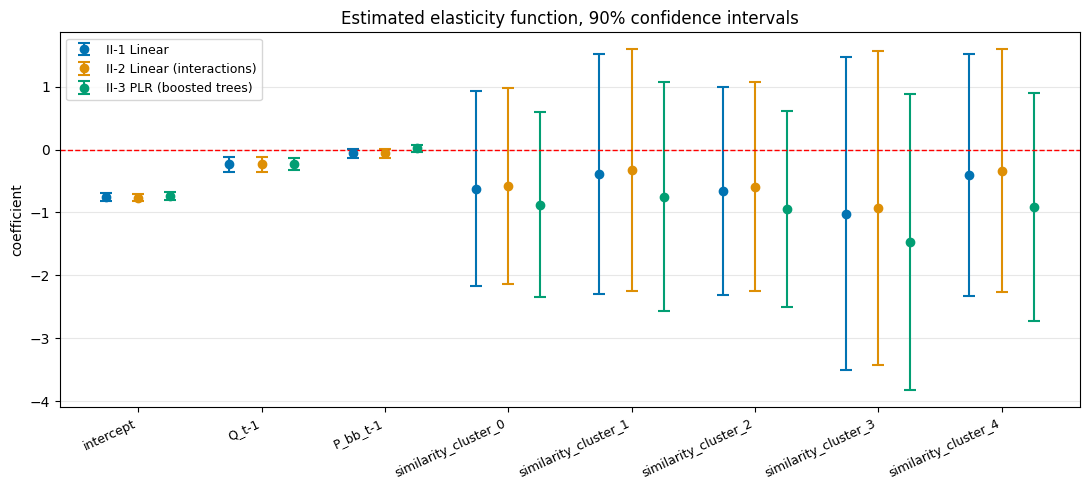

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
width = 0.26
x = np.arange(len(BASIS_COLS))

for i, (name, res) in enumerate(models.items()):
    ci = res.conf_int(alpha=1 - CONFIDENCE)
    coef = res.params.reindex(BASIS_COLS)
    lo, hi = ci[0].reindex(BASIS_COLS), ci[1].reindex(BASIS_COLS)
    ax.errorbar(x + (i - 1) * width, coef, yerr=[coef - lo, hi - coef],
                fmt="o", ms=6, capsize=4, capthick=1.5, lw=1.5,
                color=palette[i], ecolor=palette[i], label=name)

ax.axhline(0, color="red", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(BASIS_COLS, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("coefficient")
ax.set_title(f"Estimated elasticity function, {CONFIDENCE:.0%} confidence intervals")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Lagged quantity is the strongest modifier, with a coefficient of $-0.325$ and $t = -3.5$: products that already sell well lose proportionally more when their price rises. The coefficient on lagged price is small and insignificant. Several similarity coefficients are significantly negative, but the cluster numbering is arbitrary

## Joint Significance of the Effect Modifiers

The individual coefficients on the similarities are imprecise because a product's five cosine similarities are nearly collinear: they measure closeness to five centroids on a sphere, so four of them almost determine the fifth. A joint test is therefore the appropriate way to ask whether product characteristics matter at all. Because of this near-collinearity, the test uses $k-1$ degrees of freedom for $k$ tested coefficients.

In [10]:
def chi2_test(res, idx):
    """Wald test that the selected coefficients are jointly zero."""
    coef = res.params.iloc[idx].to_numpy()
    cov = res.cov_params().to_numpy()[np.ix_(idx, idx)]
    stat = coef @ np.linalg.solve(cov, coef)
    return 1 - chi2.cdf(stat, len(idx) - 1)


joint = pd.DataFrame({
    "All modifiers": {n: chi2_test(r, MOD_IDX) for n, r in models.items()},
    "Similarities only": {n: chi2_test(r, SIM_IDX) for n, r in models.items()},
})
print(f"chi-squared p-values (sample size: {len(data):,})")
joint.round(4)

chi-squared p-values (sample size: 37,940)


,All modifiers,Similarities only
II-1 Linear,0.0,0.0009
II-2 Linear (interactions),0.0,0.0013
II-3 PLR (boosted trees),0.0,0.0144


For the similarities alone, the $p$-values are 0.030 for Model II-1, 0.054 for Model II-2 and 0.001 for Model II-3.

## Group Average Effects

As a coarser analysis, we assign each observation to the cluster to which it is most similar and estimate one average effect per group (GATE).

cluster             
similarity_cluster_1    8601
similarity_cluster_4    8015
similarity_cluster_3    7834
similarity_cluster_2    7267
similarity_cluster_0    6223


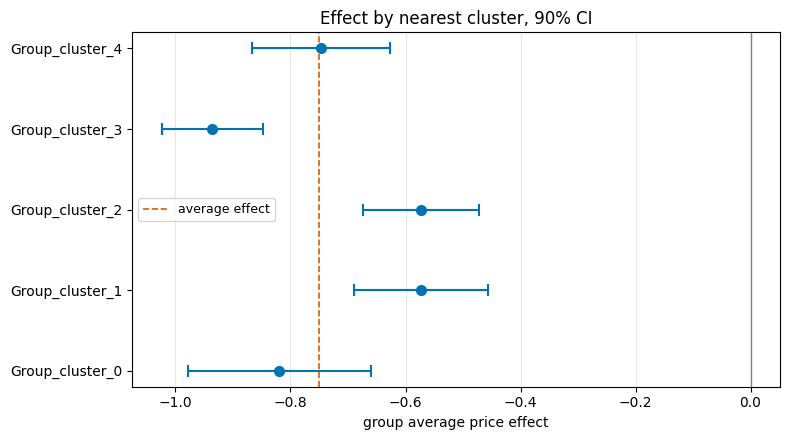

,5.0 %,effect,95.0 %
Group_similarity_cluster_0,-0.979,-0.820,-0.661
Group_similarity_cluster_1,-0.689,-0.573,-0.456
Group_similarity_cluster_2,-0.674,-0.573,-0.472
Group_similarity_cluster_3,-1.024,-0.936,-0.848
Group_similarity_cluster_4,-0.866,-0.747,-0.628


In [11]:
groups = pd.DataFrame(data[sim_cols].idxmax(axis=1), columns=["cluster"])
print(groups.value_counts().to_string())

gate = plr.gate(groups)
gate_summary = gate.confint(level=CONFIDENCE)

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(gate_summary))
coef = gate_summary.iloc[:, 1]
ax.errorbar(coef, y,
            xerr=[coef - gate_summary.iloc[:, 0], gate_summary.iloc[:, 2] - coef],
            fmt="o", ms=7, capsize=4, capthick=1.5, lw=1.5, color=palette[0])
ax.axvline(plr.coef[0], color=palette[3], ls="--", lw=1.2, label="average effect")
ax.axvline(0, color="gray", lw=1)
ax.set_yticks(y)
ax.set_yticklabels([s.replace("similarity_", "") for s in gate_summary.index])
ax.set_xlabel("group average price effect")
ax.set_title(f"Effect by nearest cluster, {CONFIDENCE:.0%} CI")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

gate_summary.round(3)

The printout reports how many observations each group contains. If the 90% confidence intervals of some groups do not overlap, the grouping by nearest cluster reveals differences in price sensitivity between groups of products.

## Sorted Effects

Next, we predict $\hat\alpha(x)$ for every observation, sort the predictions in ascending order and plot them. The spread of the resulting curve summarizes the heterogeneity.

We show two confidence bands. The pointwise band covers the elasticity at a given percentile. The uniform band, obtained by a multiplier bootstrap of the maximal $t$-statistic, covers the whole curve simultaneously. It is the relevant band when we want to claim that products at the lower end of the curve are more price-sensitive than those at the upper end.

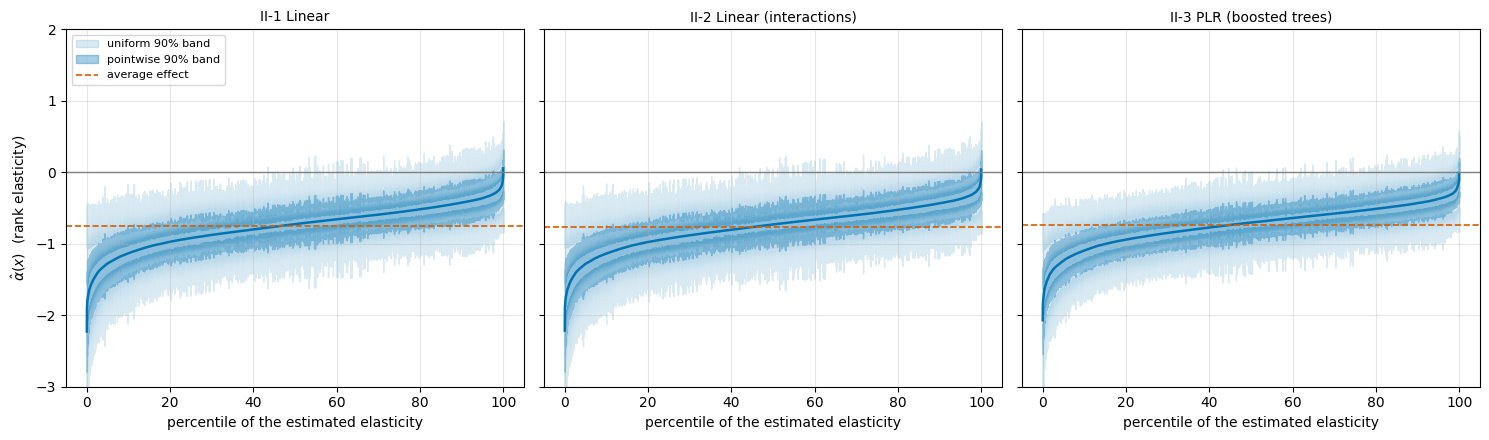

In [12]:
def effect_ci(res, basis, idx, level=CONFIDENCE, joint=False,
              n_boot=1000, seed=SEED):
    """Pointwise or uniform confidence band for basis @ coefficients."""
    b = basis.iloc[:, idx].to_numpy()
    coef = res.params.iloc[idx].to_numpy()
    cov = res.cov_params().to_numpy()[np.ix_(idx, idx)]

    effect = b @ coef
    se = np.sqrt(np.einsum("ij,jk,ik->i", b, cov, b))

    if joint:
        rng = np.random.default_rng(seed)
        root = np.real(sqrtm(cov))
        draws = (b @ root @ rng.normal(size=(len(idx), n_boot))).T / se
        crit = np.quantile(np.max(np.abs(draws), axis=0), level)
    else:
        crit = norm.ppf(0.5 + level / 2)

    return pd.DataFrame({"lower": effect - crit * se, "effect": effect,
                         "upper": effect + crit * se})


ALL_IDX = list(range(len(BASIS_COLS)))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (name, res) in zip(axes, models.items()):
    point = effect_ci(res, basis, ALL_IDX, joint=False)
    unif = effect_ci(res, basis, ALL_IDX, joint=True)
    order = np.argsort(point["effect"].values)
    pct = np.linspace(0, 100, len(order))

    ax.fill_between(pct, unif["lower"].values[order], unif["upper"].values[order],
                    color=palette[0], alpha=0.15, label="uniform 90% band")
    ax.fill_between(pct, point["lower"].values[order], point["upper"].values[order],
                    color=palette[0], alpha=0.35, label="pointwise 90% band")
    ax.plot(pct, point["effect"].values[order], color=palette[0], lw=1.8)
    ax.axhline(res.params["intercept"], color=palette[3], ls="--", lw=1.2,
               label="average effect")
    ax.axhline(0, color="gray", lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(-3, 2)
    ax.set_xlabel("percentile of the estimated elasticity")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("$\\hat{\\alpha}(x)$  (rank elasticity)")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
sorted_effects = effect_ci(models["II-3 PLR (boosted trees)"], basis, ALL_IDX)
rank = sorted_effects["effect"]

print("Estimated rank elasticity across products (Model II-3)")
print(rank.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3).to_string())
print(f"\nimplied demand elasticity, 5th to 95th percentile: "
      f"{RANK_TO_DEMAND * rank.quantile(0.05):.2f} to "
      f"{RANK_TO_DEMAND * rank.quantile(0.95):.2f}")

Estimated rank elasticity across products (Model II-3)
count    37940.000
mean        -0.739
std          0.266
min         -2.071
5%          -1.237
25%         -0.892
50%         -0.703
75%         -0.546
95%         -0.374
max         -0.010

implied demand elasticity, 5th to 95th percentile: -2.47 to -0.75


The summary describes the distribution of the estimated rank elasticities.

## Sources of Heterogeneity

The estimated elasticity is a function of seven variables. By regressing $\hat\alpha(x)$ on each block of variables in turn, we can see how the variation divides between what a product is and how popular and expensive it currently is.

In [14]:
alpha_hat = sorted_effects["effect"].values
blocks = {"256 embeddings": emb_cols,
          "5 similarities": sim_cols,
          "lagged Q, P": lag_controls}

share = {name: sm.OLS(alpha_hat, sm.add_constant(data[cols])).fit().rsquared
         for name, cols in blocks.items()}
print("share of Var(alpha-hat) explained")
for name, r2 in share.items():
    print(f"  {name:18s} {r2:6.1%}")

share of Var(alpha-hat) explained
  256 embeddings      61.7%
  5 similarities      55.1%
  lagged Q, P         82.9%


## Discussion

The three shares show how the variation of $\hat\alpha(x)$ divides between what a product is (the embeddings and the similarities) and how popular and expensive it currently is (the lagged state). The blocks can overlap, since the similarities are correlated with the lagged state, so the shares need not add up to 100%.

### The Two Roles of an Embedding

Taken together, Labs 3, 4 and 5 illustrate the paper's central claim.

| | Confounder? | Effect modifier? |
|---|---|---|
| **Evidence** | Lab 3: the embeddings barely predict $\Delta P$ | Lab 5: the joint $\chi^2$ test rejects, and $\hat\alpha(x)$ varies widely across products |
| **Consequence** | Lab 4: adding them hardly changes the estimates of $\delta$ | Lab 5: they indicate which products are more price-sensitive |

The embeddings are weak confounders but relevant effect modifiers. A model with homogeneous effects therefore recovers a reasonable average effect but is unreliable for any particular product. The value of representing products with AI methods lies less in a better estimate of the average effect than in identifying the products that the average does not describe well.